In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# loading the dataset
# Reading the CSV file into a DataFrame
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
# Filtering the DataFrame for Data Analyst jobs in India
df_DA_In = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Adding a new column for the month number of the job posted date
df_DA_In['job_posted_month_no'] = df_DA_In['job_posted_date'].dt.month

# Exploding the job_skills column to create a new row for each skill
df_DA_In_explode = df_DA_In.explode('job_skills')

 Creating a pivot table to count the number of job postings for each skill by month.

In [4]:
# The pivot table will have the month number as the index, the skills as the columns, and the count of job postings as the values. Missing values will be filled with 0.
df_DA_In_pivot = df_DA_In_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_In_pivot

job_skills,airflow,alteryx,ansible,arch,asana,asp.net,assembly,aurora,aws,azure,...,vba,visio,visual basic,vmware,watson,webex,windows,wire,word,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,0,1,0,0,0,1,0,0,6,5,...,6,1,0,0,0,1,1,0,8,0
2,1,8,0,0,0,0,0,0,6,7,...,8,0,0,0,1,0,1,0,3,0
3,1,1,1,0,0,0,0,0,7,6,...,4,0,0,0,0,0,2,0,3,0
4,0,1,0,1,0,0,1,0,4,8,...,2,2,0,0,0,0,1,0,6,0
5,0,4,0,0,0,0,0,0,4,9,...,4,0,1,0,0,0,2,0,4,0
6,1,5,0,0,0,0,0,1,10,9,...,1,0,1,1,0,0,0,0,1,0
7,3,2,0,0,0,0,0,0,5,8,...,5,0,1,0,0,0,0,0,1,0
8,7,5,0,0,0,0,0,0,20,11,...,4,0,0,0,0,0,0,0,7,0
9,1,2,0,0,1,0,0,0,12,5,...,4,2,0,2,0,0,1,0,1,0


In [5]:
# Adding a new row to the pivot table that contains the total count of job postings for each skill across all months
df_DA_In_pivot.loc['Total'] = df_DA_In_pivot.sum()

# Sorting the pivot table by the total count of job postings for each skill in descending order and dropping the 'Total' row
df_DA_In_pivot = df_DA_In_pivot[df_DA_In_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_In_pivot = df_DA_In_pivot.drop('Total')

df_DA_In_pivot

job_skills,sql,python,excel,tableau,power bi,sas,r,aws,azure,javascript,...,react.js,sqlite,suse,swift,tidyr,unify,vb.net,watson,webex,wire
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,75,55,51,41,26,36,23,6,5,11,...,0,0,0,0,0,0,0,0,1,0
2,64,40,46,32,24,14,23,6,7,8,...,0,0,0,0,0,0,0,1,0,0
3,57,25,32,30,19,10,9,7,6,3,...,0,0,1,1,0,0,0,0,0,0
4,56,35,35,27,23,24,16,4,8,7,...,1,0,0,0,0,0,0,0,0,0
5,44,25,37,24,18,10,9,4,9,3,...,0,0,0,0,0,0,0,0,0,0
6,50,42,34,29,23,28,23,10,9,5,...,0,0,0,0,0,0,0,0,0,0
7,57,37,37,38,20,20,23,5,8,5,...,0,0,0,0,1,0,0,0,0,0
8,88,58,54,47,43,24,28,20,11,7,...,0,0,0,0,0,0,0,0,0,0
9,96,65,59,53,43,26,27,12,5,14,...,0,0,0,0,0,1,0,0,0,0


### Month-by-Month Skill Demand Trends
This section tracks how key technology requirements trended throughout 2023 for Data Analysts in India. By extracting the posting month and charting the percentage ratios for the top core skills, we map out the relative market consistency and identify seasonal shifts in tool popularity.
 Plotting the top 5 skills for Data Analysts in India over time.

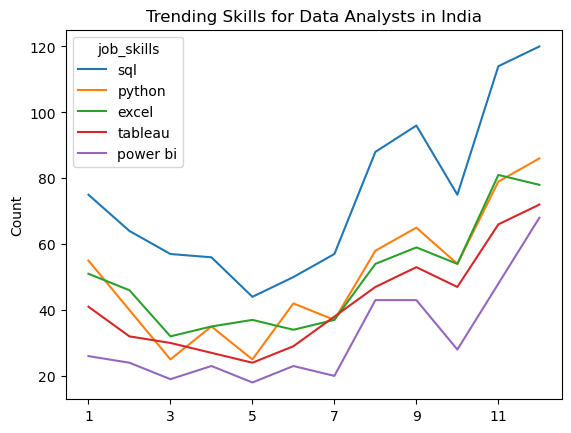

In [6]:
# The plot will show the trend of the top 5 skills in terms of job postings over the months.
df_DA_In_pivot.iloc[:, :5].plot(kind='line') # using iloc to select the first 5 columns (top 5 skills)

plt.title('Trending Skills for Data Analysts in India')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

Calculating the total number of job postings for each month.

In [7]:
# calculating by grouping the DataFrame by the 'job_posted_month_no' column and using the size() function to count the number of rows in each group
DA_totals = df_DA_In.groupby('job_posted_month_no').size()

DA_totals

job_posted_month_no
1     144
2     118
3      97
4      99
5      64
6      93
7      92
8     141
9     166
10    126
11    204
12    195
dtype: int64

Dividing the first 12 rows of df_DA_In_pivot by DA_totals.

In [8]:
# The resulting DataFrame will show the percentage of job postings for each skill in each month, relative to the total number of job postings in that month.
df_DA_In_percent = df_DA_In_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_In_percent = df_DA_In_percent.reset_index()
df_DA_In_percent['job_posted_month'] = df_DA_In_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_In_percent = df_DA_In_percent.set_index('job_posted_month')
df_DA_In_percent = df_DA_In_percent.drop(columns='job_posted_month_no')

df_DA_In_percent

job_skills,sql,python,excel,tableau,power bi,sas,r,aws,azure,javascript,...,react.js,sqlite,suse,swift,tidyr,unify,vb.net,watson,webex,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.083333,38.194444,35.416667,28.472222,18.055556,25.000000,15.972222,4.166667,3.472222,7.638889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.694444,0.000000
Feb,54.237288,33.898305,38.983051,27.118644,20.338983,11.864407,19.491525,5.084746,5.932203,6.779661,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.847458,0.000000,0.000000
Mar,58.762887,25.773196,32.989691,30.927835,19.587629,10.309278,9.278351,7.216495,6.185567,3.092784,...,0.000000,0.000000,1.030928,1.030928,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Apr,56.565657,35.353535,35.353535,27.272727,23.232323,24.242424,16.161616,4.040404,8.080808,7.070707,...,1.010101,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
May,68.750000,39.062500,57.812500,37.500000,28.125000,15.625000,14.062500,6.250000,14.062500,4.687500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jun,53.763441,45.161290,36.559140,31.182796,24.731183,30.107527,24.731183,10.752688,9.677419,5.376344,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jul,61.956522,40.217391,40.217391,41.304348,21.739130,21.739130,25.000000,5.434783,8.695652,5.434783,...,0.000000,0.000000,0.000000,0.000000,1.086957,0.00000,0.000000,0.000000,0.000000,0.000000
Aug,62.411348,41.134752,38.297872,33.333333,30.496454,17.021277,19.858156,14.184397,7.801418,4.964539,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Sep,57.831325,39.156627,35.542169,31.927711,25.903614,15.662651,16.265060,7.228916,3.012048,8.433735,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.60241,0.000000,0.000000,0.000000,0.000000


Creating a line plot to visualize the trends of the top 5 skills for Data Analysts in India over the months of 2023.

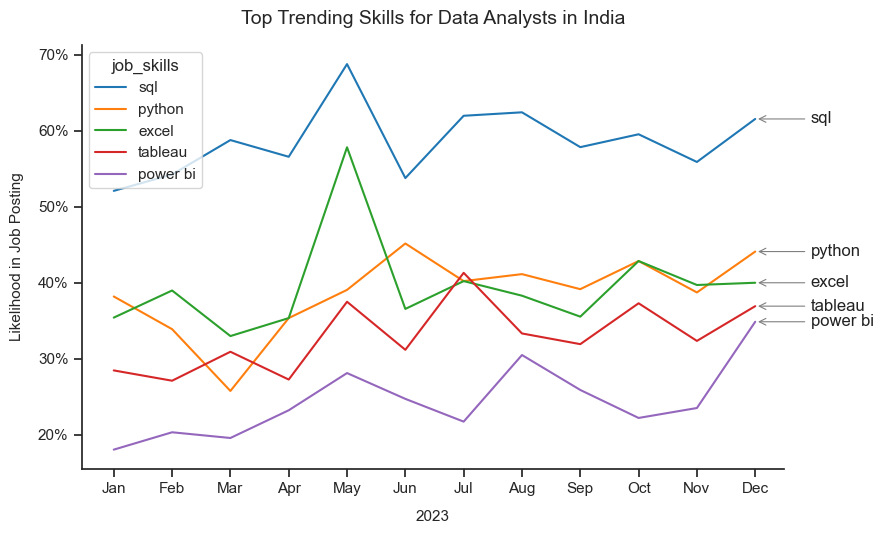

In [ ]:
from matplotlib.ticker import PercentFormatter

# Isolate the top 5 skills
df_plot = df_DA_In_percent.iloc[:, :5]

# Set up the theme and figure dimensions
sns.set_theme(style='ticks')
plt.figure(figsize=(9, 5.5))  # Gave it slightly more width for the right-side labels

# Plot the trends
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.despine()

# Styling and Titles
plt.title('Top Trending Skills for Data Analysts in India', fontsize=14, pad=15) # Added padding to the title for better spacing
plt.ylabel('Likelihood in Job Posting', fontsize=11, labelpad=10)                # Added padding to the y-axis label for better spacing
plt.xlabel('2023', fontsize=11, labelpad=10)                                     # Added padding to the x-axis label for better spacing
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Safely handle dynamic annotations using point offsets
last_month = df_plot.index[-1]

for i, col in enumerate(df_plot.columns):
    plt.annotate(
        col,
        xy=(last_month, df_plot.iloc[-1, i]),
        textcoords="offset points",  # Relative positioning instead of data-axis math
        xytext=(40, 0),  # Shifts text 40 points straight out to the right
        va='center',
        ha='left',
        color='#222222',
        arrowprops=dict(arrowstyle='->', lw=0.8, color='gray'),
    )

# Add a slight buffer to the right X-axis limit so labels have room to render
plt.gca().set_xlim(right=len(df_plot.index) - 0.5)

plt.tight_layout()
plt.show()